<a href="https://colab.research.google.com/github/aviverma02/hospital-readmission-prediction/blob/main/Hospital_Readmission_Prediction_L2_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving admissions.csv to admissions.csv
Saving billing.csv to billing.csv
Saving diagnoses.csv to diagnoses.csv
Saving hospitals.csv to hospitals.csv
Saving patients.csv to patients.csv


In [3]:
admissions = pd.read_csv("admissions.csv")
patients = pd.read_csv("patients.csv")
diagnoses = pd.read_csv("diagnoses.csv")
hospitals = pd.read_csv("hospitals.csv")
billing = pd.read_csv("billing.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [4]:
print("Admissions:", admissions.shape)
print("Patients:", patients.shape)
print("Diagnoses:", diagnoses.shape)
print("Hospitals:", hospitals.shape)
print("Billing:", billing.shape)

Admissions: (120000, 17)
Patients: (86400, 8)
Diagnoses: (271341, 6)
Hospitals: (33, 6)
Billing: (120000, 6)


In [5]:
print("Admissions Columns:")
print(admissions.columns.tolist())

print("\nPatients Columns:")
print(patients.columns.tolist())

print("\nDiagnoses Columns:")
print(diagnoses.columns.tolist())

print("\nHospitals Columns:")
print(hospitals.columns.tolist())

print("\nBilling Columns:")
print(billing.columns.tolist())

Admissions Columns:
['admission_id', 'patient_id', 'admit_date', 'discharge_date', 'los_days', 'admit_type', 'ward_type', 'hospital_id', 'discharge_type', 'num_procedures', 'charlson_index', 'hba1c', 'creatinine', 'haemoglobin', 'systolic_bp', 'readmitted_30d', 'readmitted_7d']

Patients Columns:
['patient_id', 'age', 'gender', 'state', 'bpl_card', 'insurance_type', 'comorbidity_count', 'prev_admissions']

Diagnoses Columns:
['diag_id', 'admission_id', 'icd10_code', 'diag_desc', 'diag_rank', 'diag_category']

Hospitals Columns:
['hospital_id', 'name', 'state', 'tier', 'beds', 'teaching']

Billing Columns:
['bill_id', 'admission_id', 'total_cost_inr', 'govt_subsidy_inr', 'out_of_pocket_inr', 'cost_category']


In [6]:
display(admissions.head())

,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,0,6.3,0.86,16.2,157,0,0
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,0,5.2,1.23,13.1,156,0,0
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,2,5.6,0.67,10.9,130,1,0
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,2020-03-05,2020-03-16,11,Emergency,ICU,df4431ea-1acf-4e77-963c-6173e9787151,Recovered,1,2,4.7,1.40,8.8,159,1,0
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,2018-05-30,2018-06-04,5,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,5,5.0,0.94,11.3,173,1,0


In [7]:
display(patients.head())

,patient_id,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions
0,2b179f89-9af7-45cf-86b4-3e01a47a3b7b,36,F,Telangana,False,Private,0,0
1,ecaeb9f3-d263-4712-b9b6-3312af5626ca,56,F,Uttar Pradesh,False,ESI,0,0
2,0160a5b6-877e-41e6-b84a-a2a51b367a36,67,F,Telangana,False,ESI,3,0
3,216875fa-b49d-4c47-8c8d-7191ba34ac06,53,M,Haryana,False,Ayushman,3,0
4,a2f3181d-e3f2-4fd3-8057-05a492ffcfb2,60,M,Maharashtra,True,Ayushman,4,1


In [8]:
display(diagnoses.head())

,diag_id,admission_id,icd10_code,diag_desc,diag_rank,diag_category
0,3b448b98-6b78-4c7c-94c1-f832581c5052,bcb311d6-0808-498f-8ae1-11abe1fbc08e,E87,Metabolic / electrolyte disorder,1,Endocrine
1,137c0404-f1b6-4aca-95f5-2217812a6975,996ac6db-a192-46a0-b536-503a1c57994b,J45,Asthma,1,Respiratory
2,4bfb76a1-12ed-4cbd-b905-34d4bf3196f0,cc4849fa-b740-487b-beda-3086a18273c0,G40,Epilepsy,1,Neurological
3,754ec3d2-e940-4342-9e1d-d88a9acec626,cc4849fa-b740-487b-beda-3086a18273c0,A15,Pulmonary tuberculosis,2,Infectious
4,f4fa0d7b-0a68-4dd9-b7cf-db15c6bf3812,cc4849fa-b740-487b-beda-3086a18273c0,I48,Atrial fibrillation,3,Cardiovascular


In [9]:
display(hospitals.head())

,hospital_id,name,state,tier,beds,teaching
0,df0f948a-2202-459a-ba6f-7ffd7dedcc18,Government General Hospital Maharashtra,Maharashtra,tier2,314,True
1,3d59f4a6-ce9c-4945-8f1f-5929f09a7836,Government General Hospital Uttar Pradesh,Uttar Pradesh,tier2,481,True
2,aac12881-4dea-42f3-bf32-8add9d5eee49,Government General Hospital Tamil Nadu,Tamil Nadu,tier2,428,True
3,28879338-cd09-48bb-bedb-730b8ee8ab4e,Government General Hospital Karnataka,Karnataka,tier2,304,True
4,2f5c9dbb-cef7-46a2-8f35-ac5bdc0232c6,Government General Hospital West Bengal,West Bengal,tier2,632,True


In [10]:
print(admissions["readmitted_30d"].value_counts())

readmitted_30d
0    105790
1     14210
Name: count, dtype: int64


In [11]:
print(admissions["readmitted_30d"].value_counts(normalize=True) * 100)

readmitted_30d
0    88.158333
1    11.841667
Name: proportion, dtype: float64


In [12]:
print("Admissions Missing Values:")
display(admissions.isnull().sum())

print("\nPatients Missing Values:")
display(patients.isnull().sum())

print("\nDiagnoses Missing Values:")
display(diagnoses.isnull().sum())

print("\nHospitals Missing Values:")
display(hospitals.isnull().sum())

Admissions Missing Values:


,0
admission_id,0
patient_id,0
admit_date,0
discharge_date,0
los_days,0
admit_type,0
ward_type,0
hospital_id,0
discharge_type,0
num_procedures,0



Patients Missing Values:


,0
patient_id,0
age,0
gender,0
state,0
bpl_card,0
insurance_type,24715
comorbidity_count,0
prev_admissions,0



Diagnoses Missing Values:


,0
diag_id,0
admission_id,0
icd10_code,0
diag_desc,0
diag_rank,0
diag_category,0



Hospitals Missing Values:


,0
hospital_id,0
name,0
state,0
tier,0
beds,0
teaching,0


In [13]:
print("Admissions duplicates:", admissions.duplicated().sum())
print("Patients duplicates:", patients.duplicated().sum())
print("Diagnoses duplicates:", diagnoses.duplicated().sum())
print("Hospitals duplicates:", hospitals.duplicated().sum())

Admissions duplicates: 0
Patients duplicates: 0
Diagnoses duplicates: 0
Hospitals duplicates: 0


In [14]:
print("30-Day Readmission Distribution:")
print(admissions["readmitted_30d"].value_counts())

print("\nPercentage Distribution:")
print(
    admissions["readmitted_30d"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

30-Day Readmission Distribution:
readmitted_30d
0    105790
1     14210
Name: count, dtype: int64

Percentage Distribution:
readmitted_30d
0    88.16
1    11.84
Name: proportion, dtype: float64


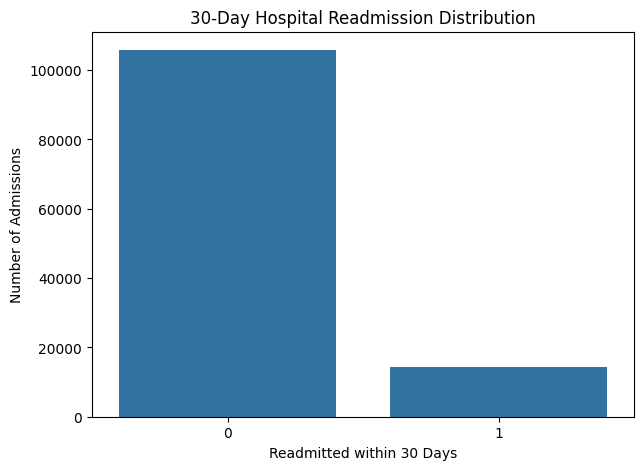

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=admissions,
    x="readmitted_30d"
)

plt.title("30-Day Hospital Readmission Distribution")
plt.xlabel("Readmitted within 30 Days")
plt.ylabel("Number of Admissions")
plt.show()

In [16]:
admissions[
    [
        "los_days",
        "num_procedures",
        "charlson_index",
        "hba1c",
        "creatinine",
        "haemoglobin",
        "systolic_bp"
    ]
].describe()

,los_days,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp
count,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,6.852708,1.523742,1.894858,5.869862,1.070463,11.840079,134.628075
std,5.708269,1.542197,1.610380,1.061662,0.896135,2.171929,20.756544
min,1.000000,0.000000,0.000000,4.000000,0.400000,4.000000,70.000000
25%,3.000000,0.000000,0.000000,5.300000,0.770000,10.400000,120.000000
50%,5.000000,1.000000,2.000000,5.700000,0.910000,11.900000,134.000000
75%,9.000000,2.000000,3.000000,6.100000,1.100000,13.300000,148.000000
max,90.000000,15.000000,6.000000,14.300000,15.000000,18.000000,220.000000


In [17]:
patients.head()

,patient_id,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions
0,2b179f89-9af7-45cf-86b4-3e01a47a3b7b,36,F,Telangana,False,Private,0,0
1,ecaeb9f3-d263-4712-b9b6-3312af5626ca,56,F,Uttar Pradesh,False,ESI,0,0
2,0160a5b6-877e-41e6-b84a-a2a51b367a36,67,F,Telangana,False,ESI,3,0
3,216875fa-b49d-4c47-8c8d-7191ba34ac06,53,M,Haryana,False,Ayushman,3,0
4,a2f3181d-e3f2-4fd3-8057-05a492ffcfb2,60,M,Maharashtra,True,Ayushman,4,1


In [18]:
patients[
    [
        "age",
        "comorbidity_count",
        "prev_admissions"
    ]
].describe()

,age,comorbidity_count,prev_admissions
count,86400.000000,86400.000000,86400.000000
mean,48.000405,1.426470,0.896076
std,21.690553,1.506211,1.083745
min,0.000000,0.000000,0.000000
25%,36.000000,0.000000,0.000000
50%,51.000000,1.000000,1.000000
75%,63.000000,2.000000,1.000000
max,95.000000,8.000000,9.000000


In [19]:
print("Admission Type:")
print(admissions["admit_type"].value_counts())

print("\nWard Type:")
print(admissions["ward_type"].value_counts())

print("\nDischarge Type:")
print(admissions["discharge_type"].value_counts())

Admission Type:
admit_type
Emergency    66540
Elective     37853
OPD          15607
Name: count, dtype: int64

Ward Type:
ward_type
General    76768
ICU        20833
HDU        15907
NICU        6492
Name: count, dtype: int64

Discharge Type:
discharge_type
Recovered    87420
LAMA         15429
Referred      9738
Expired       7413
Name: count, dtype: int64


In [20]:
print("\nGender:")
print(patients["gender"].value_counts())

print("\nInsurance Type:")
print(patients["insurance_type"].value_counts())


Gender:
gender
M        44190
F        41361
Other      849
Name: count, dtype: int64

Insurance Type:
insurance_type
Ayushman    25967
Private     21372
ESI         14346
Name: count, dtype: int64


In [21]:
print("Admissions Missing Values")
display(admissions.isnull().sum())

print("\nPatients Missing Values")
display(patients.isnull().sum())

print("\nDiagnoses Missing Values")
display(diagnoses.isnull().sum())

print("\nHospitals Missing Values")
display(hospitals.isnull().sum())

Admissions Missing Values


,0
admission_id,0
patient_id,0
admit_date,0
discharge_date,0
los_days,0
admit_type,0
ward_type,0
hospital_id,0
discharge_type,0
num_procedures,0



Patients Missing Values


,0
patient_id,0
age,0
gender,0
state,0
bpl_card,0
insurance_type,24715
comorbidity_count,0
prev_admissions,0



Diagnoses Missing Values


,0
diag_id,0
admission_id,0
icd10_code,0
diag_desc,0
diag_rank,0
diag_category,0



Hospitals Missing Values


,0
hospital_id,0
name,0
state,0
tier,0
beds,0
teaching,0


In [22]:
print("Admissions duplicates:", admissions.duplicated().sum())
print("Patients duplicates:", patients.duplicated().sum())
print("Diagnoses duplicates:", diagnoses.duplicated().sum())
print("Hospitals duplicates:", hospitals.duplicated().sum())
print("Billing duplicates:", billing.duplicated().sum())

Admissions duplicates: 0
Patients duplicates: 0
Diagnoses duplicates: 0
Hospitals duplicates: 0
Billing duplicates: 0


In [23]:
admissions = pd.read_csv("admissions.csv")
patients = pd.read_csv("patients.csv")

In [24]:
print("Admissions:", admissions.shape)
print("Patients:", patients.shape)
print("Diagnoses:", diagnoses.shape)
print("Hospitals:", hospitals.shape)
print("Billing:", billing.shape)

print("\nUnique IDs:")
print("Admission IDs:", admissions["admission_id"].nunique())
print("Patient IDs:", patients["patient_id"].nunique())
print("Hospital IDs:", hospitals["hospital_id"].nunique())

print("\nDiagnoses per admission:")
print(diagnoses.groupby("admission_id").size().describe())

Admissions: (120000, 17)
Patients: (86400, 8)
Diagnoses: (271341, 6)
Hospitals: (33, 6)
Billing: (120000, 6)

Unique IDs:
Admission IDs: 120000
Patient IDs: 86400
Hospital IDs: 33

Diagnoses per admission:
count    120000.000000
mean          2.261175
std           1.157536
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max           4.000000
dtype: float64


In [25]:
print("Duplicate patient IDs:",
      patients["patient_id"].duplicated().sum())

print("Duplicate hospital IDs:",
      hospitals["hospital_id"].duplicated().sum())

Duplicate patient IDs: 0
Duplicate hospital IDs: 0


In [26]:
diagnosis_features = diagnoses.groupby("admission_id").agg(
    diagnosis_count=("icd10_code", "count"),
    primary_diagnosis=("icd10_code", "first"),
    primary_diagnosis_category=("diag_category", "first")
).reset_index()

print("Diagnosis features shape:", diagnosis_features.shape)

display(diagnosis_features.head())

Diagnosis features shape: (120000, 4)


,admission_id,diagnosis_count,primary_diagnosis,primary_diagnosis_category
0,0001273a-4e21-47f3-8dff-877734fb010c,1,C50,Neoplasm
1,00020220-ca07-4b22-bed3-934e565d2875,1,O34,Obstetric
2,0003b202-ff44-43ac-bc52-6075f4ecddf9,3,E10,Endocrine
3,0004897e-6c81-44ed-bc91-b9ae47bedced,3,G40,Neurological
4,000616dc-80eb-4a95-a8cd-60245916a9a9,3,P22,Perinatal


In [27]:
data = admissions.merge(
    patients,
    on="patient_id",
    how="left"
)

print("After merging patients:", data.shape)
display(data.head())

After merging patients: (120000, 24)


,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,...,systolic_bp,readmitted_30d,readmitted_7d,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,...,157,0,0,46,M,Haryana,False,ESI,0,0
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,...,156,0,0,31,M,Andhra Pradesh,False,NaN,0,0
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,...,130,1,0,53,F,West Bengal,False,Private,2,3
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,2020-03-05,2020-03-16,11,Emergency,ICU,df4431ea-1acf-4e77-963c-6173e9787151,Recovered,1,...,159,1,0,56,F,Kerala,False,NaN,0,1
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,2018-05-30,2018-06-04,5,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,...,173,1,0,69,F,Kerala,False,NaN,2,0


In [28]:
data = data.merge(
    diagnosis_features,
    on="admission_id",
    how="left"
)

print("After merging diagnoses:", data.shape)
display(data.head())

After merging diagnoses: (120000, 27)


,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,...,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions,diagnosis_count,primary_diagnosis,primary_diagnosis_category
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,...,46,M,Haryana,False,ESI,0,0,1,E87,Endocrine
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,...,31,M,Andhra Pradesh,False,NaN,0,0,1,J45,Respiratory
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,...,53,F,West Bengal,False,Private,2,3,3,G40,Neurological
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,2020-03-05,2020-03-16,11,Emergency,ICU,df4431ea-1acf-4e77-963c-6173e9787151,Recovered,1,...,56,F,Kerala,False,NaN,0,1,1,I50,Cardiovascular
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,2018-05-30,2018-06-04,5,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,...,69,F,Kerala,False,NaN,2,0,3,C50,Neoplasm


In [29]:
data = data.merge(
    hospitals,
    on="hospital_id",
    how="left"
)

print("Final dataset shape:", data.shape)
display(data.head())

Final dataset shape: (120000, 32)


,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,...,comorbidity_count,prev_admissions,diagnosis_count,primary_diagnosis,primary_diagnosis_category,name,state_y,tier,beds,teaching
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,...,0,0,1,E87,Endocrine,Government General Hospital Odisha,Odisha,tier2,359,True
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,...,0,0,1,J45,Respiratory,District Hospital Madhya Pradesh,Madhya Pradesh,tier3,67,False
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,...,2,3,3,G40,Neurological,Apollo/Manipal (Private) Karnataka,Karnataka,tier1,1018,True
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,2020-03-05,2020-03-16,11,Emergency,ICU,df4431ea-1acf-4e77-963c-6173e9787151,Recovered,1,...,0,1,1,I50,Cardiovascular,District Hospital Uttar Pradesh,Uttar Pradesh,tier3,191,False
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,2018-05-30,2018-06-04,5,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,...,2,0,3,C50,Neoplasm,District Hospital Madhya Pradesh,Madhya Pradesh,tier3,67,False


In [30]:
print("Final Columns:")
for i, col in enumerate(data.columns, 1):
    print(i, ":", col)

Final Columns:
1 : admission_id
2 : patient_id
3 : admit_date
4 : discharge_date
5 : los_days
6 : admit_type
7 : ward_type
8 : hospital_id
9 : discharge_type
10 : num_procedures
11 : charlson_index
12 : hba1c
13 : creatinine
14 : haemoglobin
15 : systolic_bp
16 : readmitted_30d
17 : readmitted_7d
18 : age
19 : gender
20 : state_x
21 : bpl_card
22 : insurance_type
23 : comorbidity_count
24 : prev_admissions
25 : diagnosis_count
26 : primary_diagnosis
27 : primary_diagnosis_category
28 : name
29 : state_y
30 : tier
31 : beds
32 : teaching


In [31]:
print("Target distribution:")
print(data["readmitted_30d"].value_counts())

print("\nTarget percentage:")
print(
    data["readmitted_30d"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target distribution:
readmitted_30d
0    105790
1     14210
Name: count, dtype: int64

Target percentage:
readmitted_30d
0    88.16
1    11.84
Name: proportion, dtype: float64


In [32]:
features = [
    # Patient information
    "age",
    "gender",
    "insurance_type",
    "comorbidity_count",
    "prev_admissions",

    # Admission information
    "admit_type",
    "ward_type",
    "discharge_type",
    "num_procedures",
    "charlson_index",

    # Clinical measurements
    "hba1c",
    "creatinine",
    "haemoglobin",
    "systolic_bp",

    # Diagnosis information
    "diagnosis_count",
    "primary_diagnosis_category",

    # Hospital information
    "tier",
    "beds",
    "teaching"
]

target = "readmitted_30d"

X = data[features].copy()
y = data[target].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Feature shape: (120000, 19)
Target shape: (120000,)


,age,gender,insurance_type,comorbidity_count,prev_admissions,admit_type,ward_type,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,diagnosis_count,primary_diagnosis_category,tier,beds,teaching
0,46,M,ESI,0,0,Elective,General,Recovered,0,0,6.3,0.86,16.2,157,1,Endocrine,tier2,359,True
1,31,M,NaN,0,0,OPD,General,Recovered,1,0,5.2,1.23,13.1,156,1,Respiratory,tier3,67,False
2,53,F,Private,2,3,Emergency,General,Recovered,0,2,5.6,0.67,10.9,130,3,Neurological,tier1,1018,True
3,56,F,NaN,0,1,Emergency,ICU,Recovered,1,2,4.7,1.40,8.8,159,1,Cardiovascular,tier3,191,False
4,69,F,NaN,2,0,Emergency,General,Recovered,1,5,5.0,0.94,11.3,173,3,Neoplasm,tier3,67,False


In [33]:
print("Missing values in selected features:")
display(X.isnull().sum().sort_values(ascending=False))

Missing values in selected features:


,0
insurance_type,33987
age,0
gender,0
comorbidity_count,0
prev_admissions,0
admit_type,0
ward_type,0
discharge_type,0
num_procedures,0
charlson_index,0


In [34]:
missing_percentage = (
    X.isnull().mean() * 100
).sort_values(ascending=False)

display(missing_percentage)

,0
insurance_type,28.3225
age,0.0000
gender,0.0000
comorbidity_count,0.0000
prev_admissions,0.0000
admit_type,0.0000
ward_type,0.0000
discharge_type,0.0000
num_procedures,0.0000
charlson_index,0.0000


In [35]:
print("Feature Data Types:")
print(X.dtypes)

Feature Data Types:
age                             int64
gender                         object
insurance_type                 object
comorbidity_count               int64
prev_admissions                 int64
admit_type                     object
ward_type                      object
discharge_type                 object
num_procedures                  int64
charlson_index                  int64
hba1c                         float64
creatinine                    float64
haemoglobin                   float64
systolic_bp                     int64
diagnosis_count                 int64
primary_diagnosis_category     object
tier                           object
beds                            int64
teaching                         bool
dtype: object


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 96000
Testing samples: 24000

Training target distribution:
readmitted_30d
0    84632
1    11368
Name: count, dtype: int64

Testing target distribution:
readmitted_30d
0    21158
1     2842
Name: count, dtype: int64


In [37]:
numeric_features = [
    "age",
    "comorbidity_count",
    "prev_admissions",
    "num_procedures",
    "charlson_index",
    "hba1c",
    "creatinine",
    "haemoglobin",
    "systolic_bp",
    "diagnosis_count",
    "beds"
]

categorical_features = [
    "gender",
    "insurance_type",
    "admit_type",
    "ward_type",
    "discharge_type",
    "primary_diagnosis_category",
    "tier",
    "teaching"
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'comorbidity_count', 'prev_admissions', 'num_procedures', 'charlson_index', 'hba1c', 'creatinine', 'haemoglobin', 'systolic_bp', 'diagnosis_count', 'beds']

Categorical features:
['gender', 'insurance_type', 'admit_type', 'ward_type', 'discharge_type', 'primary_diagnosis_category', 'tier', 'teaching']


In [38]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [39]:
logistic_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000,
    random_state=42
)

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [40]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", logistic_model)
    ]
)

print("Complete ML pipeline created successfully!")

Complete ML pipeline created successfully!


In [42]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [43]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
[0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]


In [44]:
y_prob = model.predict_proba(X_test)[:, 1]

print("Prediction probabilities:")
print(y_prob[:20])

Prediction probabilities:
[1.01308836e-01 1.85400481e-01 6.61114623e-02 2.38328627e-02
 5.46453505e-02 5.33773729e-04 4.39856019e-02 1.14932966e-01
 3.86993208e-02 5.35828232e-01 2.09541219e-01 7.79720221e-02
 6.28698495e-04 2.11123119e-01 1.82300510e-01 1.16581629e-01
 6.48423850e-02 3.10822138e-01 1.44140245e-01 1.04599613e-01]


In [45]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Model Evaluation")
print("------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Model Evaluation
------------------------
Accuracy : 0.8848
Precision: 0.6203
Recall   : 0.069
F1 Score : 0.1241


In [46]:
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc_score, 4))

ROC-AUC Score: 0.774


In [47]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Readmitted", "Readmitted"],
    zero_division=0
))

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.89      0.99      0.94     21158
    Readmitted       0.62      0.07      0.12      2842

      accuracy                           0.88     24000
     macro avg       0.75      0.53      0.53     24000
  weighted avg       0.86      0.88      0.84     24000



In [48]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[21038   120]
 [ 2646   196]]


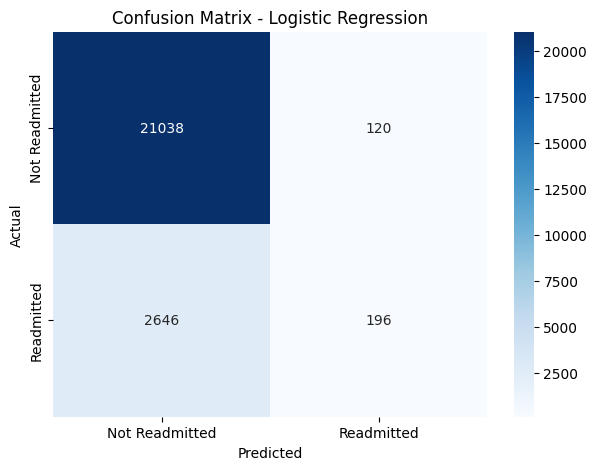

In [49]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Readmitted", "Readmitted"],
    yticklabels=["Not Readmitted", "Readmitted"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [50]:
tn, fp, fn, tp = cm.ravel()

print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)

True Negative (TN): 21038
False Positive (FP): 120
False Negative (FN): 2646
True Positive (TP): 196


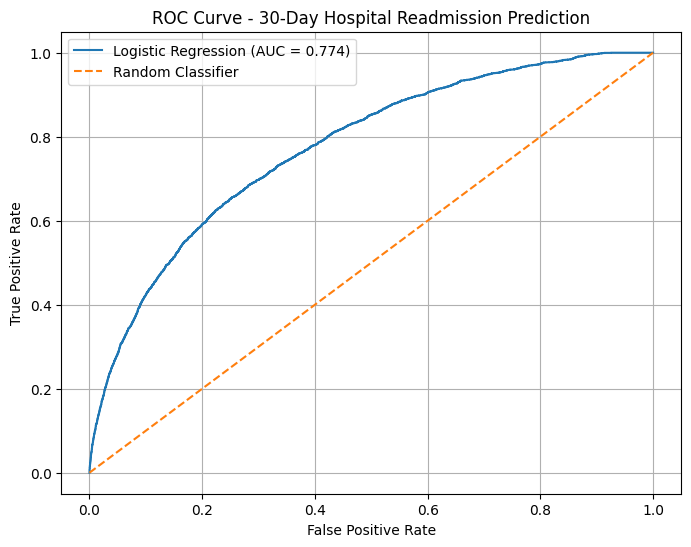

In [51]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30-Day Hospital Readmission Prediction")
plt.legend()
plt.grid()
plt.show()

In [52]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "False Positives",
        "False Negatives"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        auc_score,
        fp,
        fn
    ]
})

display(results)

,Metric,Value
0,Accuracy,0.884750
1,Precision,0.620253
2,Recall,0.068966
3,F1 Score,0.124129
4,ROC-AUC,0.773982
5,False Positives,120.000000
6,False Negatives,2646.000000


In [53]:
thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds_to_test:
    y_threshold = (y_prob >= threshold).astype(int)

    cm_threshold = confusion_matrix(y_test, y_threshold)
    tn_t, fp_t, fn_t, tp_t = cm_threshold.ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_threshold, zero_division=0),
        "F1 Score": f1_score(y_test, y_threshold, zero_division=0),
        "False Positives": fp_t,
        "False Negatives": fn_t
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(4))

,Threshold,Precision,Recall,F1 Score,False Positives,False Negatives
0,0.3,0.4390,0.2748,0.3380,998,2061
1,0.4,0.5269,0.1450,0.2274,370,2430
2,0.5,0.6203,0.0690,0.1241,120,2646
3,0.6,0.6789,0.0260,0.0502,35,2768
4,0.7,0.7353,0.0088,0.0174,9,2817


In [54]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["classifier"].coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(coefficient_df.head(20))

,Feature,Coefficient,Absolute_Coefficient
25,cat__discharge_type_Expired,-4.157381,4.157381
26,cat__discharge_type_LAMA,1.380479,1.380479
27,cat__discharge_type_Recovered,0.924503,0.924503
28,cat__discharge_type_Referred,0.904837,0.904837
21,cat__ward_type_General,-0.885221,0.885221
16,cat__insurance_type_Private,-0.538823,0.538823
37,cat__primary_diagnosis_category_Obstetric,-0.524571,0.524571
43,cat__teaching_False,-0.491946,0.491946
44,cat__teaching_True,-0.455615,0.455615
20,cat__admit_type_OPD,-0.413069,0.413069


In [55]:
positive_features = coefficient_df[
    coefficient_df["Coefficient"] > 0
].sort_values(
    "Coefficient",
    ascending=False
)

display(positive_features.head(10))

,Feature,Coefficient,Absolute_Coefficient
26,cat__discharge_type_LAMA,1.380479,1.380479
27,cat__discharge_type_Recovered,0.924503,0.924503
28,cat__discharge_type_Referred,0.904837,0.904837
23,cat__ward_type_ICU,0.377189,0.377189
1,num__comorbidity_count,0.357313,0.357313
38,cat__primary_diagnosis_category_Perinatal,0.242703,0.242703
35,cat__primary_diagnosis_category_Neoplasm,0.209338,0.209338
2,num__prev_admissions,0.182932,0.182932
0,num__age,0.140068,0.140068
4,num__charlson_index,0.073326,0.073326


In [56]:
negative_features = coefficient_df[
    coefficient_df["Coefficient"] < 0
].sort_values(
    "Coefficient",
    ascending=True
)

display(negative_features.head(10))

,Feature,Coefficient,Absolute_Coefficient
25,cat__discharge_type_Expired,-4.157381,4.157381
21,cat__ward_type_General,-0.885221,0.885221
16,cat__insurance_type_Private,-0.538823,0.538823
37,cat__primary_diagnosis_category_Obstetric,-0.524571,0.524571
43,cat__teaching_False,-0.491946,0.491946
44,cat__teaching_True,-0.455615,0.455615
20,cat__admit_type_OPD,-0.413069,0.413069
22,cat__ward_type_HDU,-0.370280,0.370280
18,cat__admit_type_Elective,-0.367195,0.367195
29,cat__primary_diagnosis_category_Cardiovascular,-0.348006,0.348006


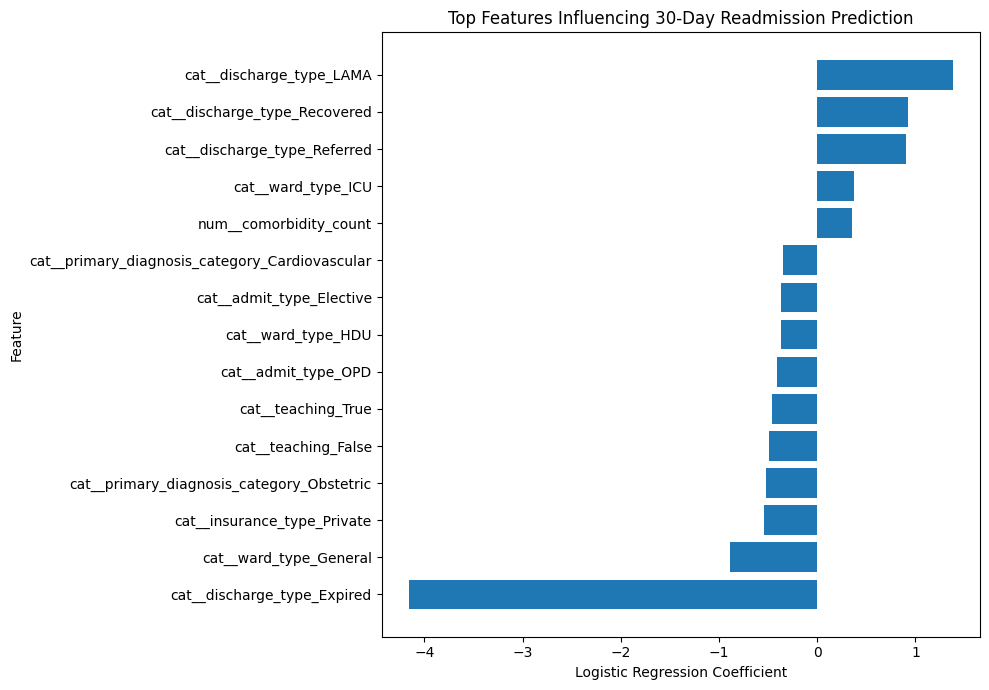

In [57]:
top_features = coefficient_df.head(15).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Influencing 30-Day Readmission Prediction")

plt.tight_layout()
plt.show()

In [58]:
threshold = 0.40

y_pred_40 = (y_prob >= threshold).astype(int)

cm_40 = confusion_matrix(y_test, y_pred_40)

tn_40, fp_40, fn_40, tp_40 = cm_40.ravel()

print("Threshold:", threshold)
print("----------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred_40), 4))
print("Precision:", round(precision_score(y_test, y_pred_40, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_40, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_40, zero_division=0), 4))
print("FP       :", fp_40)
print("FN       :", fn_40)

Threshold: 0.4
----------------------
Accuracy : 0.8833
Precision: 0.5269
Recall   : 0.145
F1 Score : 0.2274
FP       : 370
FN       : 2430


In [59]:
import joblib

joblib.dump(model, "hospital_readmission_logistic_l2.pkl")

print("Model saved successfully!")

Model saved successfully!


In [60]:
from google.colab import files

files.download("hospital_readmission_logistic_l2.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>